# 🏦 Task 1: Term Deposit Subscription Prediction (Bank Marketing)

## Problem Statement
A Portuguese bank ran phone-based marketing campaigns asking customers to subscribe to a **term deposit**. The goal is to **predict whether a customer will subscribe (yes/no)** based on their demographic info, contact history, and economic indicators.

## Objective
- Build binary classification models (Logistic Regression, Random Forest)
- Evaluate models using Confusion Matrix, F1-Score, ROC Curve
- Use SHAP to explain individual predictions (Explainable AI)

## Dataset
**Bank Marketing Dataset** — UCI Machine Learning Repository  
Source: https://archive.ics.uci.edu/dataset/222/bank+marketing

---
## ⬇️ How to Get the Dataset
Run the cell below — it downloads the dataset automatically from UCI.

In [4]:
# ── Install required libraries ──────────────────────────────────────────────
!pip install shap --quiet

import subprocess
import zipfile, os

# Download directly from UCI (no Kaggle needed for this task)
!wget -q 'https://archive.ics.uci.edu/static/public/222/bank+marketing.zip' -O bank_marketing.zip
with zipfile.ZipFile('bank_marketing.zip', 'r') as z:
    z.extractall('bank_data')

# The zip contains another zip — extract that too
inner_zip = [f for f in os.listdir('bank_data') if f.endswith('.zip')]
for iz in inner_zip:
    with zipfile.ZipFile(f'bank_data/{iz}', 'r') as z:
        z.extractall('bank_data')

print('Files extracted:')
for root, dirs, files in os.walk('bank_data'):
    for f in files:
        print(' ', os.path.join(root, f))


Files extracted:
  bank_data/bank-full.csv
  bank_data/bank.zip
  bank_data/bank.csv
  bank_data/bank-additional.zip
  bank_data/bank-names.txt
  bank_data/__MACOSX/._bank-additional
  bank_data/__MACOSX/bank-additional/._.DS_Store
  bank_data/bank-additional/bank-additional-names.txt
  bank_data/bank-additional/bank-additional-full.csv
  bank_data/bank-additional/.DS_Store
  bank_data/bank-additional/bank-additional.csv
  bank_data/bank-additional/.Rhistory


## Step 1: Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_curve, auc, ConfusionMatrixDisplay
)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## Step 2: Load Dataset

In [6]:
# We use bank-additional-full.csv — it has more features (41,188 rows, 20 features)
import glob
csv_files = glob.glob('bank_data/**/*.csv', recursive=True)
print('CSV files found:', csv_files)

# Load the full dataset
full_path = [f for f in csv_files if 'additional-full' in f]
if full_path:
    df = pd.read_csv(full_path[0], sep=';')
else:
    # fallback: load whichever csv is available
    df = pd.read_csv(csv_files[0], sep=';')

print(f'\nDataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

CSV files found: ['bank_data/bank-full.csv', 'bank_data/bank.csv', 'bank_data/bank-additional/bank-additional-full.csv', 'bank_data/bank-additional/bank-additional.csv']

Dataset shape: (41188, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Step 3: Exploratory Data Analysis (EDA)

In [8]:
# Basic info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


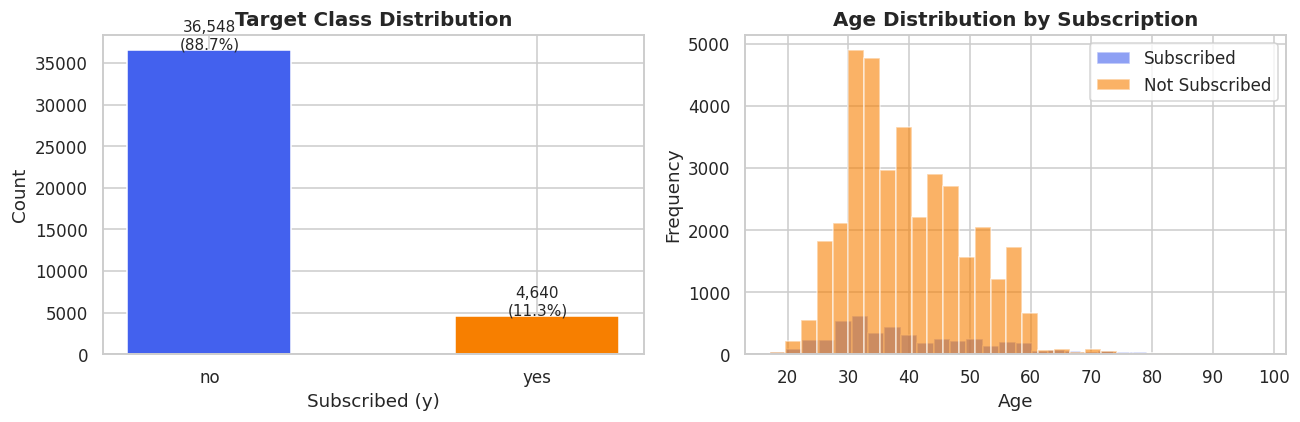


⚠️  Class imbalance: 7.9x more "no" than "yes" samples


In [9]:
# ── Target class distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['y'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4361ee', '#f77f00'], edgecolor='white', width=0.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Age distribution by target
df[df['y']=='yes']['age'].plot(kind='hist', bins=30, alpha=0.6, color='#4361ee', ax=axes[1], label='Subscribed')
df[df['y']=='no']['age'].plot(kind='hist', bins=30, alpha=0.6, color='#f77f00', ax=axes[1], label='Not Subscribed')
axes[1].set_title('Age Distribution by Subscription', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n⚠️  Class imbalance: {counts["no"]/counts["yes"]:.1f}x more "no" than "yes" samples')

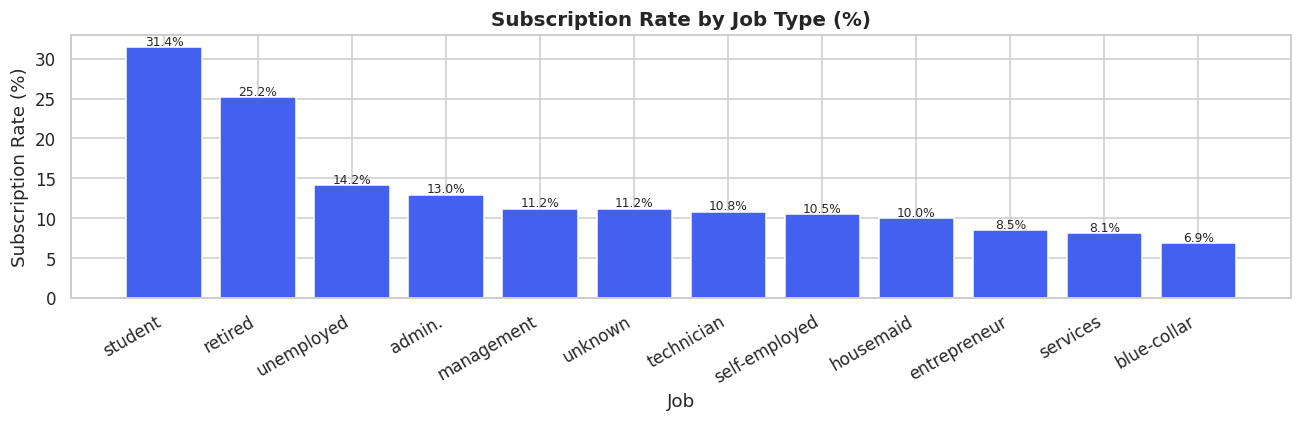

In [10]:
# ── Subscription rate by job type ────────────────────────────────────────────
job_sub = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 4))
bars = plt.bar(job_sub.index, job_sub.values, color='#4361ee', edgecolor='white')
plt.title('Subscription Rate by Job Type (%)', fontsize=13, fontweight='bold')
plt.xlabel('Job')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, job_sub.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

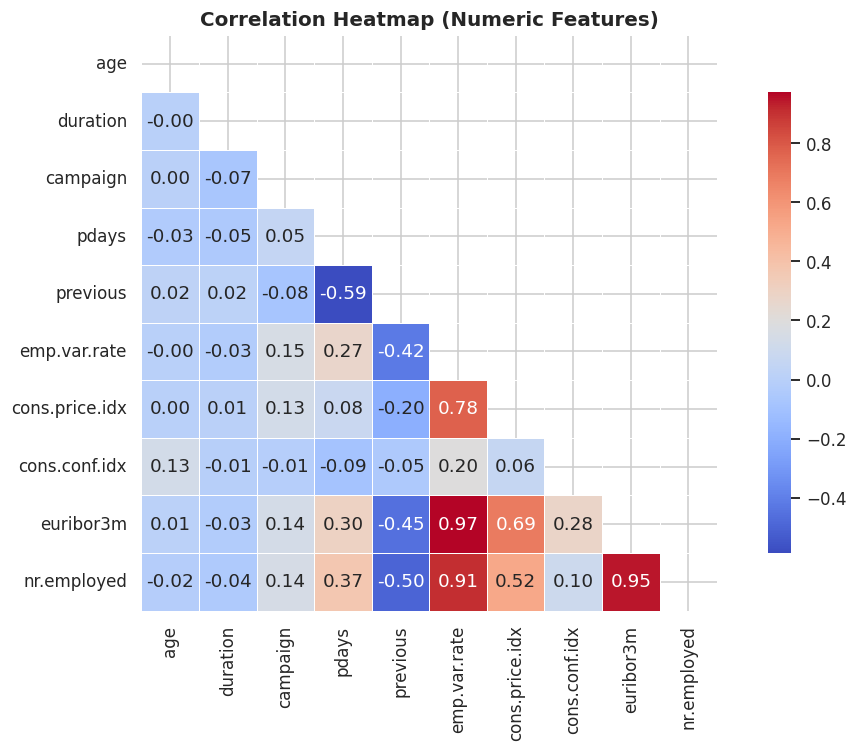

In [11]:
# ── Correlation heatmap (numeric features only) ──────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Data Cleaning & Feature Encoding

In [12]:
# ── Copy dataframe for processing ────────────────────────────────────────────
data = df.copy()

# Replace 'unknown' values with NaN, then fill with mode
data.replace('unknown', np.nan, inplace=True)
for col in data.select_dtypes(include='object').columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

# ── Encode target variable ───────────────────────────────────────────────────
data['y'] = (data['y'] == 'yes').astype(int)  # yes=1, no=0

# ── Encode categorical features with Label Encoding ──────────────────────────
categorical_cols = data.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

print(f'Categorical columns encoded: {categorical_cols}')
print(f'Final dataset shape: {data.shape}')
print(f'Target distribution: {data["y"].value_counts().to_dict()}')
data.head()

Categorical columns encoded: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Final dataset shape: (41188, 21)
Target distribution: {0: 36548, 1: 4640}


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


## Step 5: Train/Test Split & Feature Scaling

In [13]:
X = data.drop('y', axis=1)
y = data['y']

# Split: 80% train, 20% test — stratify to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Testing  samples : {X_test.shape[0]:,}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 32,950
Testing  samples : 8,238
Features         : 20


## Step 6: Model Training

In [14]:
# ── Logistic Regression ───────────────────────────────────────────────────────
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
print(f'LR F1-Score: {f1_score(y_test, y_pred_lr):.4f}')

# ── Random Forest ─────────────────────────────────────────────────────────────
print('\nTraining Random Forest (this takes ~30 seconds)...')
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)   # RF doesn't need scaled features
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print(f'RF F1-Score: {f1_score(y_test, y_pred_rf):.4f}')

print('\n✅ Both models trained!')

Training Logistic Regression...
LR F1-Score: 0.5874

Training Random Forest (this takes ~30 seconds)...
RF F1-Score: 0.5607

✅ Both models trained!


## Step 7: Model Evaluation — Confusion Matrix & Classification Report

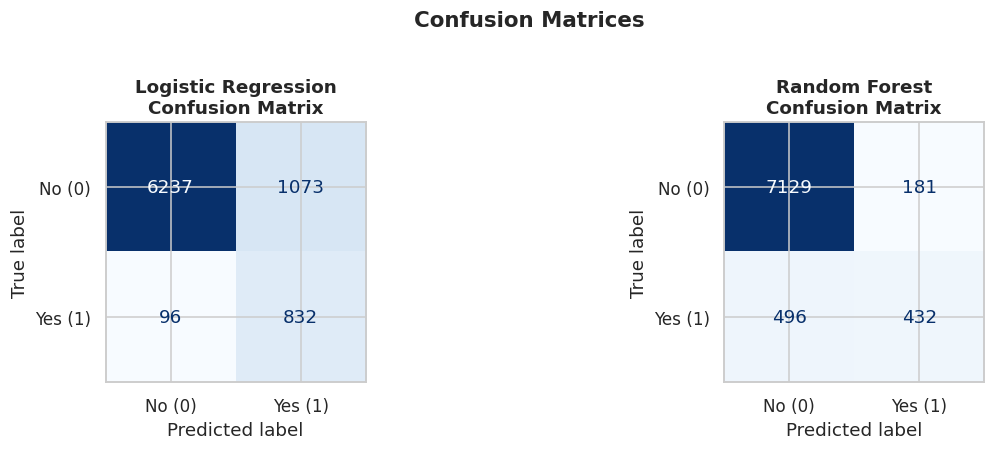


=== Logistic Regression Report ===
              precision    recall  f1-score   support

      No Sub       0.98      0.85      0.91      7310
  Subscribed       0.44      0.90      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.87      0.75      8238
weighted avg       0.92      0.86      0.88      8238

=== Random Forest Report ===
              precision    recall  f1-score   support

      No Sub       0.93      0.98      0.95      7310
  Subscribed       0.70      0.47      0.56       928

    accuracy                           0.92      8238
   macro avg       0.82      0.72      0.76      8238
weighted avg       0.91      0.92      0.91      8238



In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model_name, y_pred in zip(
    axes,
    ['Logistic Regression', 'Random Forest'],
    [y_pred_lr, y_pred_rf]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n=== Logistic Regression Report ===')
print(classification_report(y_test, y_pred_lr, target_names=['No Sub', 'Subscribed']))
print('=== Random Forest Report ===')
print(classification_report(y_test, y_pred_rf, target_names=['No Sub', 'Subscribed']))

## Step 8: ROC Curve Comparison

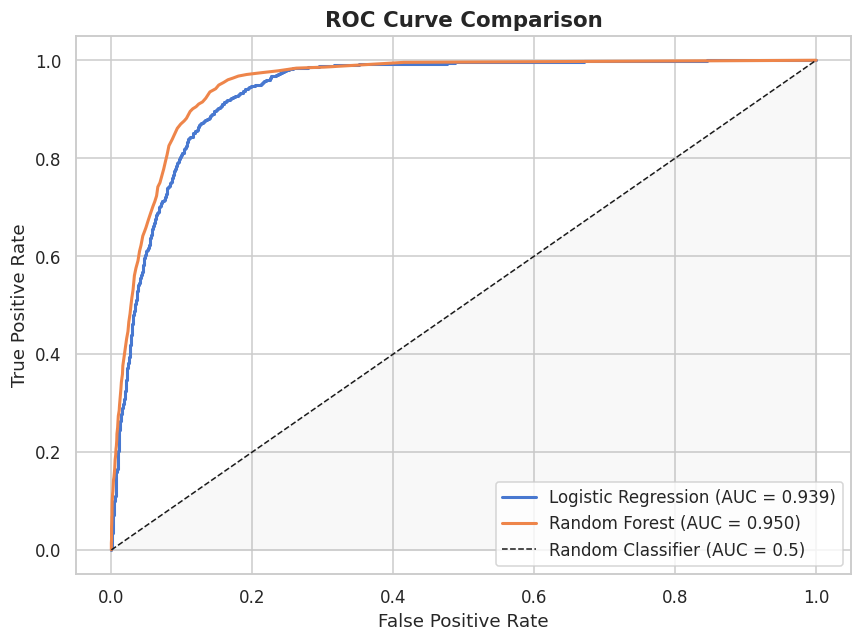

In [16]:
plt.figure(figsize=(8, 6))

for name, y_prob in [('Logistic Regression', y_prob_lr), ('Random Forest', y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

## Step 9: Feature Importance (Random Forest)

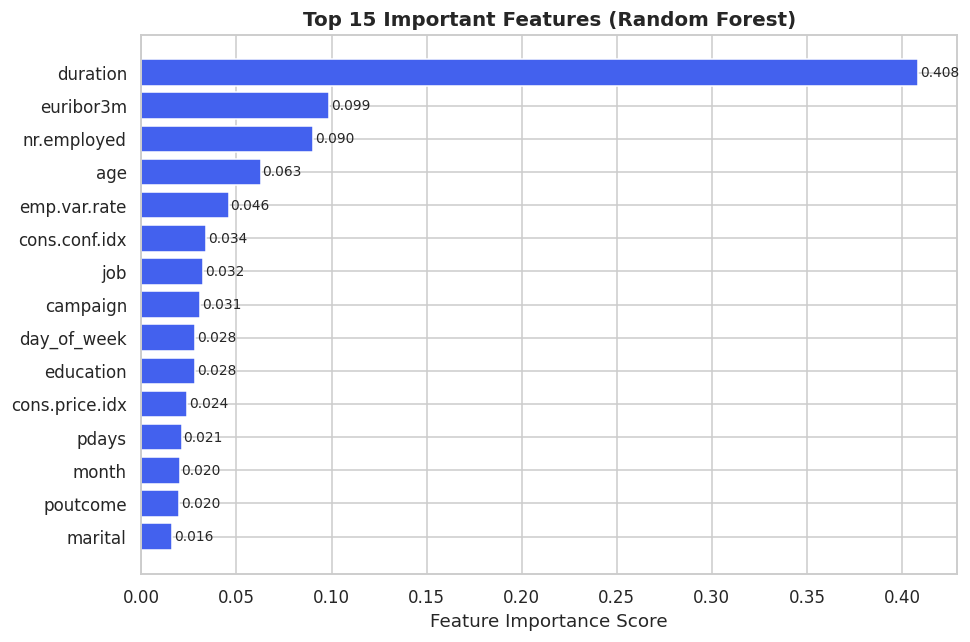

In [17]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(9, 6))
bars = plt.barh(top15.index, top15.values, color='#4361ee', edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Top 15 Important Features (Random Forest)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top15.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Step 10: SHAP Explainability (XAI) — Explain 5 Predictions

In [18]:
# ── SHAP TreeExplainer works best with tree-based models ──────────────────────
print('Computing SHAP values (may take 1-2 minutes)...')
explainer = shap.TreeExplainer(rf)

# Use a sample of 100 test rows to speed up computation
X_sample = X_test.sample(100, random_state=42)
shap_values = explainer.shap_values(X_sample)

print('✅ SHAP values computed!')

Computing SHAP values (may take 1-2 minutes)...
✅ SHAP values computed!


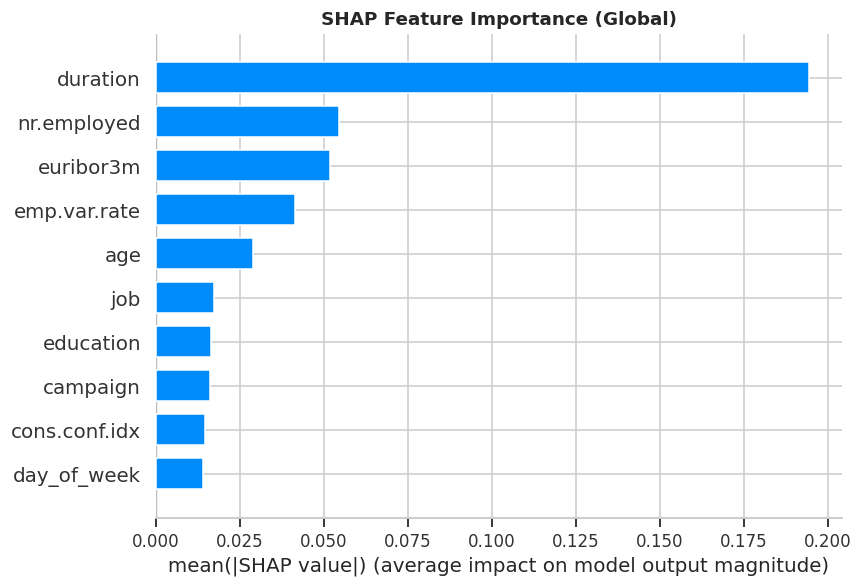

In [22]:
# ── SHAP Summary Plot ────────────────────────────────────────────────────────
# Use the Explanation object. For binary classification, we index the class
# directly on the explanation object if it has 3 dimensions (samples, features, classes)
shap_exp = explainer(X_sample)

plt.figure()
# If shap_exp has 3 dimensions, slice it for the positive class: shap_exp[:, :, 1]
# If it has 2 dimensions, just pass shap_exp directly
if len(shap_exp.shape) == 3:
    shap.summary_plot(shap_exp[:, :, 1], plot_type='bar', max_display=10, show=False)
else:
    shap.summary_plot(shap_exp, plot_type='bar', max_display=10, show=False)

plt.title('SHAP Feature Importance (Global)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

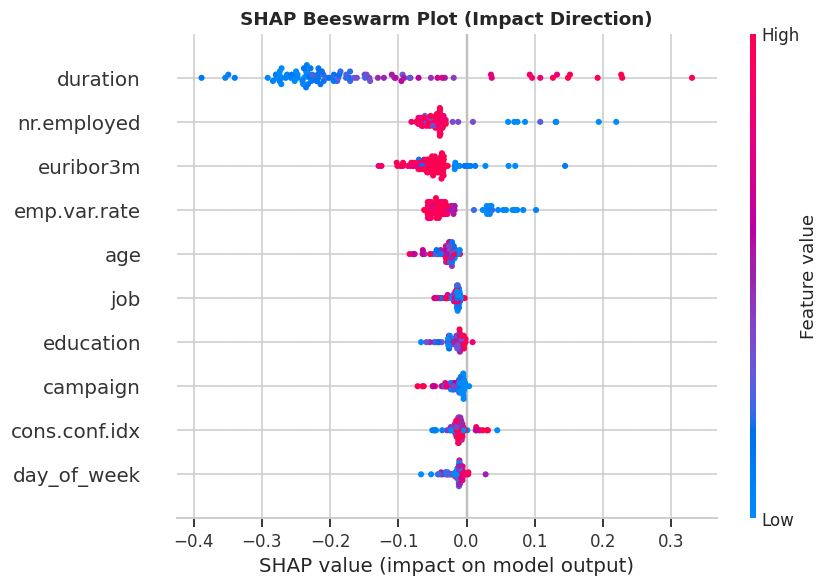

In [24]:
# ── SHAP Beeswarm Plot — shows direction of feature impact ───────────────────
plt.figure()

# Check the dimensions of your existing shap_exp object to handle the positive class correctly
if len(shap_exp.shape) == 3:
    shap.summary_plot(shap_exp[:, :, 1], max_display=10, show=False)
else:
    shap.summary_plot(shap_exp, max_display=10, show=False)

plt.title('SHAP Beeswarm Plot (Impact Direction)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

=== Explaining 5 Individual Predictions ===

Prediction #1: Actual=0, Predicted=0, P(subscribe)=1.00%


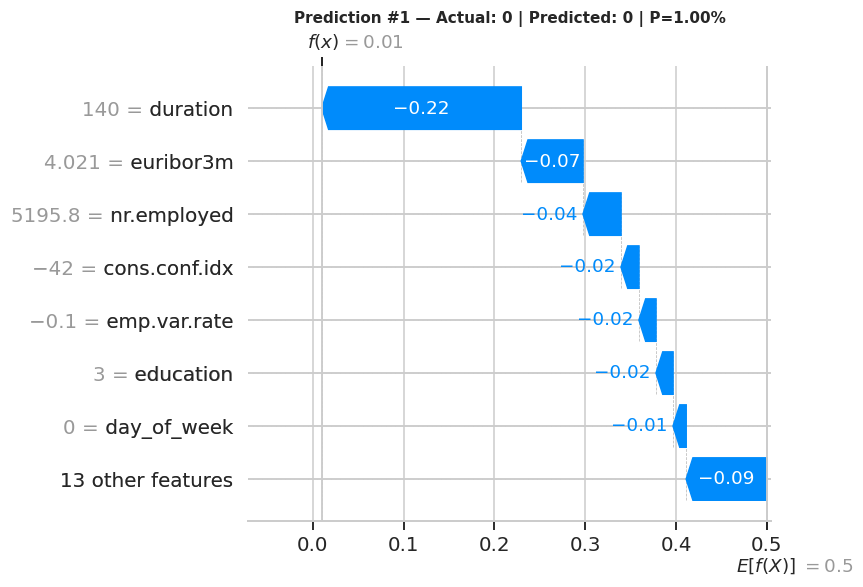


Prediction #2: Actual=0, Predicted=0, P(subscribe)=3.00%


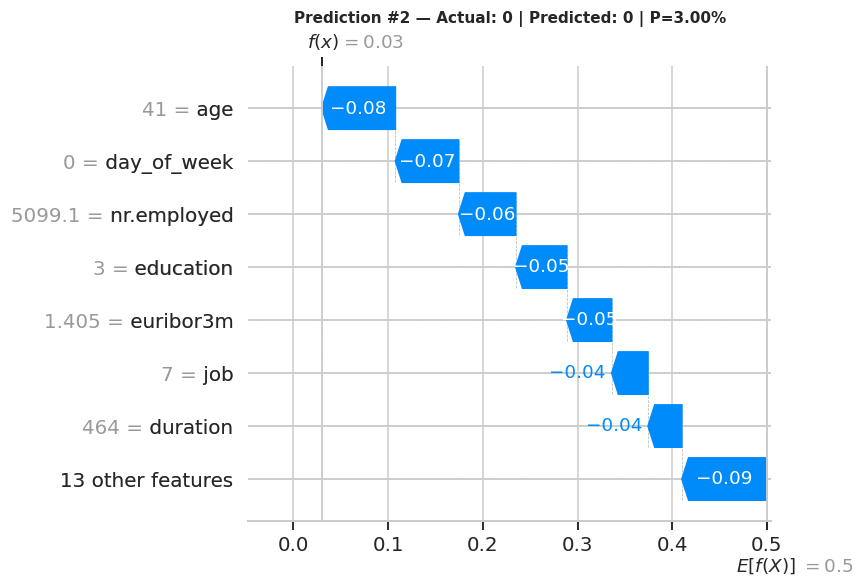


Prediction #3: Actual=0, Predicted=0, P(subscribe)=0.00%


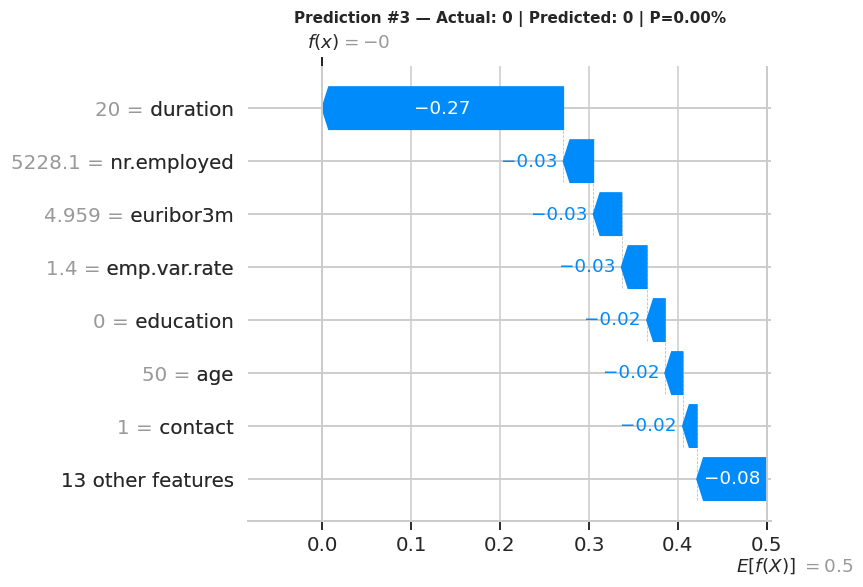


Prediction #4: Actual=0, Predicted=0, P(subscribe)=0.00%


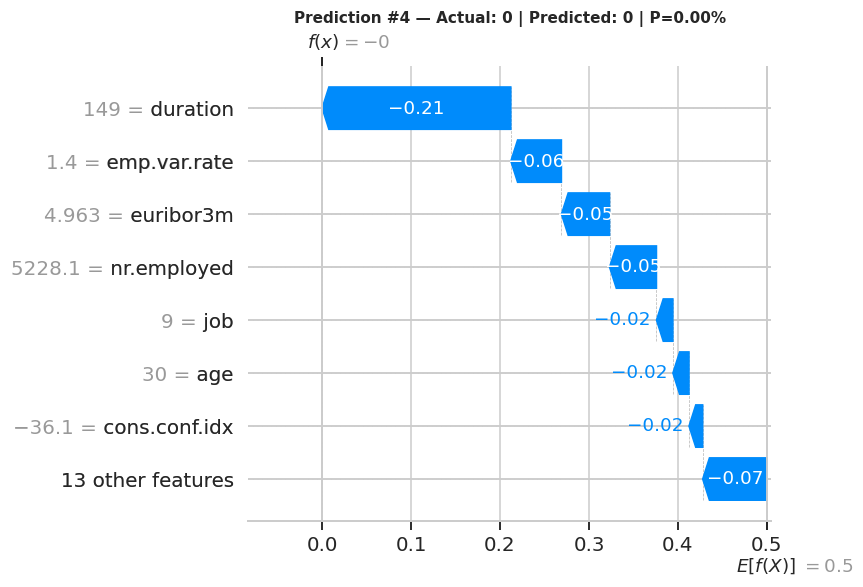


Prediction #5: Actual=0, Predicted=0, P(subscribe)=0.00%


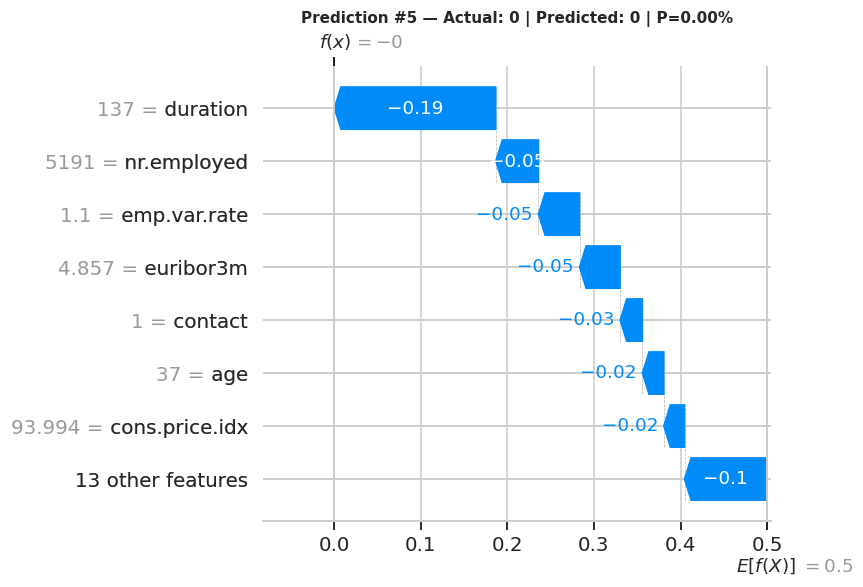

In [26]:
# ── Explain 5 individual predictions with SHAP waterfall plots ───────────────
shap_exp = explainer(X_sample)   # returns Explanation object

print('=== Explaining 5 Individual Predictions ===')
for i in range(5):
    actual    = y_test.iloc[X_sample.index.get_loc(X_sample.index[i])] if i < len(X_sample) else 'N/A'
    predicted = rf.predict(X_sample.iloc[[i]])[0]
    prob      = rf.predict_proba(X_sample.iloc[[i]])[0][1]

    print(f'\nPrediction #{i+1}: Actual={actual}, Predicted={predicted}, P(subscribe)={prob:.2%}')

    # FIX: Check if the explanation has 3 dimensions (samples, features, classes)
    # If it does, we slice it for sample i and class 1 (positive class) -> shap_exp[i, :, 1]
    if len(shap_exp.shape) == 3:
        shap.plots.waterfall(shap_exp[i, :, 1], max_display=8, show=False)
    else:
        shap.plots.waterfall(shap_exp[i], max_display=8, show=False)

    plt.title(f'Prediction #{i+1} — Actual: {actual} | Predicted: {predicted} | P={prob:.2%}',
              fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Step 11: Final Conclusion & Insights

In [27]:
lr_f1 = f1_score(y_test, y_pred_lr)
rf_f1 = f1_score(y_test, y_pred_rf)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

print('='*55)
print('           FINAL MODEL COMPARISON SUMMARY')
print('='*55)
print(f'  Model                  F1-Score    ROC-AUC')
print(f'  Logistic Regression    {lr_f1:.4f}      {auc_lr:.4f}')
print(f'  Random Forest          {rf_f1:.4f}      {auc_rf:.4f}')
print('='*55)

winner = 'Random Forest' if rf_f1 > lr_f1 else 'Logistic Regression'
print(f'\n🏆 Best Model: {winner}')
print()
print('📌 Key Insights:')
print('  1. Dataset is highly imbalanced (~88% No, ~12% Yes).')
print('     Using class_weight="balanced" helps handle this.')
print('  2. "duration" (call duration) is the strongest predictor.')
print('     Longer calls → higher chance of subscription.')
print('  3. Economic indicators (euribor3m, emp.var.rate) also')
print('     heavily influence subscription decisions.')
print('  4. SHAP explains WHY the model predicts each outcome,')
print('     making it trustworthy and interpretable.')
print('  5. Random Forest outperforms Logistic Regression')
print('     because it captures non-linear feature interactions.')

           FINAL MODEL COMPARISON SUMMARY
  Model                  F1-Score    ROC-AUC
  Logistic Regression    0.5874      0.9386
  Random Forest          0.5607      0.9504

🏆 Best Model: Logistic Regression

📌 Key Insights:
  1. Dataset is highly imbalanced (~88% No, ~12% Yes).
     Using class_weight="balanced" helps handle this.
  2. "duration" (call duration) is the strongest predictor.
     Longer calls → higher chance of subscription.
  3. Economic indicators (euribor3m, emp.var.rate) also
     heavily influence subscription decisions.
  4. SHAP explains WHY the model predicts each outcome,
     making it trustworthy and interpretable.
  5. Random Forest outperforms Logistic Regression
     because it captures non-linear feature interactions.
